# Neural Symbolic Regression from Truncated Taylor Series

In [52]:
import json
import random
import re
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
import matplotlib.pyplot as plt
from sympy import symbols, sin, cos, exp, series, simplify, expand


## Dataset Preprocessing

To build the dataset we take inspiration from the *FASEROH* paper, where the key idea is to generate a sufficiently diverse set of functions that cover the space of expressions commonly used in physics and mathematics.  

The first step is to define a small inventory of base functions (e.g. `x`, `x²`, `sin(x)`, `cos(x)`, `exp(x)`) that can be combined with simple operators. This defines our "grammar" of symbolic expressions.  

Once a random function is generated, we use **Sympy** to compute its Taylor expansion around 0, truncated at the fourth order. Each pair *(function, expansion)* is then tokenized and stored, forming the dataset used to train the seq2seq model.


In [53]:
# Symbol for Sympy expansions
x = symbols('x', real=True)

BASE_FUNCTIONS = [x, x**2, x**3, sin(x), cos(x), exp(x)]
OPERATORS = ['+', '-', '*', '/']

def generate_random_function():
    """
    Generates a random function by combining base functions explicitly.
    """
    num_terms = random.randint(1, 3)  
    f = random.choice(BASE_FUNCTIONS)
    
    for _ in range(num_terms - 1):
        operator = random.choice(OPERATORS)
        next_function = random.choice(BASE_FUNCTIONS)
        
        if operator == '/':
            # Ensure we are not dividing by an expression that can become zero
            if next_function != 0 and next_function != x - x:  
                f = f / next_function
        elif operator == '+':
            f = f + next_function
        elif operator == '-':
            f = f - next_function
        elif operator == '*':
            f = f * next_function

    f = simplify(expand(f))
    
    # Avoid returning 0
    if f == 0:
        return generate_random_function()  # Ricrea una funzione se otteniamo zero
    
    return f

def compute_taylor_expansion(f, x, order=4):
    """
    Computes and simplifies the Taylor's series expansion of a function around x=0.
    Default up to order=4.
    """
    try:
        expansion = series(f, x, 0, order+1).removeO()
        return simplify(expansion)
    except Exception:
        return None

def tokenize(expression_str):
    """
    Tokenizes a mathematical expression into a list of tokens
    """
    expression_str = str(expression_str).replace("**", "^")  
    
    expression_str = re.sub(r'([+\-*/^()])', r' \1 ', expression_str)
    
    expression_str = re.sub(r'(\s)-(\d+(\.\d*)?)', r' \1\2', expression_str)

    expression_str = re.sub(r'\b(sin|cos|exp|log|tan|sqrt)\s*\(', r' \1 ( ', expression_str)
    
    tokens = expression_str.strip().split()
    
    return tokens

In [54]:
def generate_dataset(num_samples=10000, filename="dataset.json", taylor_order=6):
    """
    Generates (function, taylor_expansion) pairs, each tokenized.
    Saves them into a JSON file: [ { "function": [...], "expansion": [...] }, ... ]
    This is usefull because we are going to use it later to train the LSTM
    """
    data = []
    for _ in range(num_samples):
        f = generate_random_function()
        expansion = compute_taylor_expansion(f, x, order=taylor_order)
        
        f_str = str(f)
        expansion_str = str(expansion)
        
        data.append({
            "function": tokenize(f_str),
            "expansion": tokenize(expansion_str)
        })
    
    with open(filename, "w") as fp:
        json.dump(data, fp, indent=4)
    


# generate_dataset(num_samples=200000, filename="dataset.json", taylor_order=4)


Now we can see how our helper functions builds the dataset

In [55]:
# Randomly creating a function
for i in range(10):
   print(generate_random_function())

x**3 + 2*exp(x)
exp(x) + cos(x)
x**2
sin(x)
sin(x)
x**2*exp(x)
x**2
1
x**2*cos(x)
x**2*(x + cos(x))


In [56]:
# Creating the taylor expansion
for i in range(10):
   print(compute_taylor_expansion(generate_random_function(),x))

x**4/24 - 3*x**2/2 + 1
x**3
x*(-x**2/6 + x + 1)
x**2 + 1
x**3*(1 - x)
x**4/24 - x**2/2 + 1
x**4
-x**3/6 + x
x**4/120 + 5*x**2/6 + 1
x*(x**2/3 + x + 1)


In [57]:
# How the dataset is tokenized
for i in range(10):
   print(tokenize(str(compute_taylor_expansion(generate_random_function(),x))))

['x', '^', '3']
['x', '*', '(', '-', 'x', '^', '2', '/', '6', '+', 'x', '+', '1', ')']
['x', '^', '3']
['x', '^', '4', '/', '24', '-', 'x', '^', '2', '/', '2', '+', '1']
['-', 'x', '^', '3', '/', '6', '+', 'x']
['x', '*', '(', 'x', '^', '2', '/', '6', '+', 'x', '-', '1', ')']
['x', '^', '4', '/', '24', '-', 'x', '^', '3', '-', 'x', '^', '2', '/', '2', '+', '1']
['x', '^', '4', '/', '24', '+', 'x', '^', '2', '/', '2', '+', '2', '*', 'x', '+', '1']
['x', '^', '3']
['x', '^', '4', '/', '24', '+', 'x', '^', '3', '/', '6', '+', 'x', '^', '2', '/', '2', '+', 'x', '+', '1']


Now we need a vocab, with unique entries to tokenize the dataset, knowing that we are going to need in a index format for training the LSTM(added also the token for SOS , EOS and PAD)

In [58]:
# Load the dataset
with open("dataset.json", "r") as fp:
    dataset = json.load(fp)


all_tokens = set()
for entry in dataset:
    for t in entry["function"]:
        all_tokens.add(t)
    for t in entry["expansion"]:
        all_tokens.add(t)


special_tokens = ["<PAD>", "<SOS>", "<EOS>", "<UNK>"]


vocab = {}
for i, st in enumerate(special_tokens):
    vocab[st] = i

offset = len(special_tokens)  
for idx, token in enumerate(sorted(all_tokens)):
    
    if token not in vocab:
        vocab[token] = idx + offset

# Build the reverse mapping
idx_to_token = {v: k for k, v in vocab.items()}


PAD_TOKEN = vocab["<PAD>"]
SOS_TOKEN = vocab["<SOS>"]
EOS_TOKEN = vocab["<EOS>"]
UNK_TOKEN = vocab["<UNK>"]

vocab_size = len(vocab)
print("Vocabulary size:", vocab_size)
print("Sample vocab items:", list(vocab.items())[:20])


Vocabulary size: 161
Sample vocab items: [('<PAD>', 0), ('<SOS>', 1), ('<EOS>', 2), ('<UNK>', 3), ('(', 4), (')', 5), ('*', 6), ('+', 7), ('-', 8), ('/', 9), ('1', 10), ('10', 11), ('100', 12), ('10080', 13), ('103', 14), ('105', 15), ('1080', 16), ('11', 17), ('112', 18), ('114', 19)]


In [59]:
def tokens_to_ids(tokens, vocab, unk_token=UNK_TOKEN):
    return [vocab[token] if token in vocab else unk_token for token in tokens]

numerical_data = []
for entry in dataset:
    func_ids = tokens_to_ids(entry["function"], vocab)
    exp_ids  = tokens_to_ids(entry["expansion"], vocab)
    numerical_data.append({
        "function": func_ids,
        "expansion": exp_ids
    })

with open("numerical_dataset.json", "w") as fp:
    json.dump(numerical_data, fp, indent=4)

print(f"Saved numerical dataset with {len(numerical_data)} samples.")


Saved numerical dataset with 137732 samples.


So basically now we have a dataset containing pair of fucntion and their taylor expansion. We already created the numerical dataset used to train the LSTM model.

## LSTM model
 
Now the goal is to use the dataset created to train a type of RNN called LSTM. Briefly recall of what this architecture are : A Recurrent Neural Network (RNN) is a type of artificial neural network designed to handle sequential data, such as time series, text, speech, and videos. Unlike feedforward neural networks, which process inputs independently, RNNs have a built-in memory mechanism that allows them to maintain contextual information across different time steps.

Key Characteristics of RNNs

Sequential Processing – Unlike traditional neural networks that treat each input independently, RNNs process sequences step by step, maintaining a state (hidden representation) that captures information from previous time steps.
Shared Weights – The same weights (parameters) are used at each time step, reducing the number of parameters compared to deep feedforward networks and making RNNs more efficient for sequential tasks.
Hidden State – RNNs maintain a hidden state 
h
t
h 
t
​	
  that acts as a memory, capturing past information.
Backpropagation Through Time (BPTT) – The training of RNNs involves unrolling the network through time and applying backpropagation to update weights.
Challenges of Standard RNNs


Key Components of an LSTM Cell

Forget Gate: Decides what portion of past information should be discarded.
Input Gate: Determines how much new information should be stored in the memory.
Cell State: Acts as a long-term memory that carries relevant information through time.
Output Gate: Controls what information from the cell state should be output at the current step.
By controlling the flow of information explicitly, LSTMs mitigate the vanishing gradient problem and improve the handling of long sequences.

The pipeline that we are going to apply for training the LSTM  : 
1. Creating our dataloader taylored for our purpose
2. Defining the model with the parameters
3. Training Loop
4. Evaluation test

In [60]:
class TaylorDataset(Dataset):
    """
    Loads the numerical data in memory. Each item is:
    {
      "function": [int, int, int, ...],
      "expansion": [int, int, int, ...]
    }
    We ll make the expansion the encoder input, and function the decoder target.
    """
    def __init__(self, json_path):
        super().__init__()
        with open(json_path, "r") as fp:
            self.data = json.load(fp)
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        item = self.data[idx]
        
        exp_seq = item["expansion"]
        func_seq = item["function"]
        
        func_seq_in  = [SOS_TOKEN] + func_seq
        func_seq_out = func_seq + [EOS_TOKEN]
        
        return {
            "expansion": torch.tensor(exp_seq, dtype=torch.long),
            "function_in": torch.tensor(func_seq_in, dtype=torch.long),
            "function_out": torch.tensor(func_seq_out, dtype=torch.long)
        }

def collate_fn(batch):
    """
    We need to pad the sequence given the architecture.
    Given a list of items from TaylorDataset.getitem(), produce:
      exps_padded, exp_lengths, funcs_in_padded, funcs_out_padded, func_lengths
    """
    exps      = [b["expansion"]    for b in batch]
    funcs_in  = [b["function_in"]  for b in batch]
    funcs_out = [b["function_out"] for b in batch]
    
    exp_lengths  = torch.tensor([len(seq) for seq in exps],      dtype=torch.long)
    func_lengths = torch.tensor([len(seq) for seq in funcs_in],  dtype=torch.long)
    
    exps_padded      = pad_sequence(exps,      batch_first=True, padding_value=PAD_TOKEN)
    funcs_in_padded  = pad_sequence(funcs_in,  batch_first=True, padding_value=PAD_TOKEN)
    funcs_out_padded = pad_sequence(funcs_out, batch_first=True, padding_value=PAD_TOKEN)
    
    return (
        exps_padded,      # [B, max_len_exp]
        exp_lengths,      # [B]
        funcs_in_padded,  # [B, max_len_func]
        funcs_out_padded, # [B, max_len_func]
        func_lengths      # [B]
    )


dataset_obj = TaylorDataset("numerical_dataset.json")
train_loader = DataLoader(
    dataset_obj,
    batch_size=256,
    shuffle=True,
    collate_fn=collate_fn
)


In [61]:
# This is how a batch is retrieved
for batch in train_loader:
   exps_padded, exp_lengths, funcs_in_padded, funcs_out_padded, func_lengths = batch
   
   print("\n--- Example Batch ---")
   print(f"Expansions (padded): \n{exps_padded}")
   print(f"Expansions lengths: {exp_lengths}")
   print(f"Function Inputs (padded): \n{funcs_in_padded}")
   print(f"Function Outputs (padded): \n{funcs_out_padded}")
   print(f"Function lengths: {func_lengths}")
   break  


--- Example Batch ---
Expansions (padded): 
tensor([[  8,  51,   6,  ...,   0,   0,   0],
        [160, 153,  92,  ...,   0,   0,   0],
        [160, 153,  92,  ...,   0,   0,   0],
        ...,
        [160, 153,  74,  ...,   0,   0,   0],
        [160, 153,  92,  ...,   0,   0,   0],
        [  4, 160,   6,  ...,   0,   0,   0]])
Expansions lengths: tensor([10, 13, 21,  8, 14,  8, 28, 13, 17, 21,  8, 20, 17, 15, 13,  8, 13,  8,
        21, 13, 13,  9, 16, 13, 10, 20, 13,  8,  8, 19, 21, 20, 21,  5, 27, 28,
        21,  8, 14, 23,  8, 21, 18,  7, 17, 13, 20, 21, 10, 22,  8, 13, 10, 21,
        13, 23, 21, 21, 21, 16, 10, 23, 13, 14,  9, 13, 11,  8, 27, 13, 23, 23,
        13, 27, 13, 10,  8,  8, 26, 21,  8, 13, 21,  8, 16, 13, 16, 17, 13,  7,
         6, 23, 43, 13, 18, 22, 15, 15, 13, 11, 20, 19, 19,  9,  8,  8, 23, 25,
         8, 13,  8, 22,  8,  8, 21, 16, 15, 21, 36,  3, 13, 23, 18, 21, 27, 35,
        19, 14, 17, 21, 21, 34, 23,  8, 22, 21, 13, 13,  9, 45, 21, 25,  8, 13,
     

To solve this task, we can use a basic sequence-to-sequence (seq2seq) model with LSTMs. This consists of:
An Encoder: Converts the Taylor expansion into a context vector,
A Decoder: Uses the context vector to generate the original function.

In [62]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=1, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=pad_idx
        )
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout = 0.4
        )
    
    def forward(self, input_seqs, seq_lengths):
        # input_seqs: [B, T]
        embedded = self.embedding(input_seqs)  # [B, T, embed_dim]
        packed_embedded = pack_padded_sequence(
            embedded,
            seq_lengths.cpu(),  
            batch_first=True,
            enforce_sorted=False
        )
        _, (hidden, cell) = self.lstm(packed_embedded)
        return hidden, cell


class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=1, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embed_dim,
            padding_idx=pad_idx
        )
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.4
        )
        self.fc = nn.Linear(hidden_dim, vocab_size)
    
    def forward(self, input_seqs, hidden, cell):
        # input_seqs: [B, T_dec]
        embedded = self.embedding(input_seqs)  # [B, T_dec, embed_dim]
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        logits = self.fc(output)  # [B, T_dec, vocab_size]
        return logits, hidden, cell

# Simple wrapper to batch everything
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
    
    def forward(self, src, src_lengths, trg):
        """
        src: [B, T_enc]
        src_lengths: [B]
        trg: [B, T_dec], where T_dec includes <SOS> at the beginning
        """
        hidden, cell = self.encoder(src, src_lengths)
        outputs, _, _ = self.decoder(trg, hidden, cell)
        return outputs


In [63]:
import os, json, random, torch, numpy as np

SEED = 0
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("Device:", device)


Device: cuda


In [64]:
# Hyperparam section
VOCAB_SIZE = vocab_size
EMBED_DIM = 150
HIDDEN_DIM = 512
NUM_LAYERS = 2
LR = 1e-3
NUM_EPOCHS = 2

# MPS check(I trained it on my laptop:) )
# if torch.backends.mps.is_available():
#   device = torch.device("mps")
#   print("Using Apple Silicon MPS backend.")

In [65]:
# Model definition

encoder = Encoder(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    pad_idx=PAD_TOKEN
)
decoder = Decoder(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    pad_idx=PAD_TOKEN
)
model = Seq2Seq(encoder, decoder).to(device)

In [66]:
# Optimization setup
criterion = nn.CrossEntropyLoss(ignore_index=PAD_TOKEN, label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)


In [ ]:
from tqdm import tqdm

# Training Loop
for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0
    
    print(f"\n=== Epoch {epoch+1}/{NUM_EPOCHS} ===")
    
    for batch_idx, batch in enumerate(tqdm(train_loader, desc="Training", leave=False), 1):
        exps_padded, exp_lengths, funcs_in_padded, funcs_out_padded, func_lengths = [
            b.to(device) for b in batch
        ]
        
        # Forward pass
        logits = model(exps_padded, exp_lengths, funcs_in_padded)
        B, T_dec, V = logits.shape
        
        # Compute loss
        loss = criterion(logits.view(B*T_dec, V), funcs_out_padded.view(B*T_dec))
        
        # Backprop
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # grad clipping
        optimizer.step()
        
        total_loss += loss.item()
        
        if batch_idx % 270 == 0 or batch_idx == len(train_loader):
            avg_batch_loss = total_loss / batch_idx
            print(f"  Batch {batch_idx}/{len(train_loader)} | Avg Loss: {avg_batch_loss:.4f}")
    
    # Epoch summary
    avg_epoch_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1} completed | Avg Train Loss: {avg_epoch_loss:.4f}")
    
    scheduler.step(avg_epoch_loss)



=== Epoch 1/2 ===


Training:  47%|████▋     | 253/539 [00:11<00:13, 21.98it/s]

  Batch 250/539 | Avg Loss: 1.4387


Training:  93%|█████████▎| 502/539 [00:22<00:01, 22.06it/s]

  Batch 500/539 | Avg Loss: 1.2088


...

Training:  47%|████▋     | 254/539 [00:11<00:13, 20.64it/s]

  Batch 250/539 | Avg Loss: 0.9049


Training:  93%|█████████▎| 503/539 [00:23<00:01, 21.38it/s]

  Batch 500/539 | Avg Loss: 0.8909


  Batch 539/539 | Avg Loss: 0.8894
Epoch 2 completed | Avg Train Loss: 0.8894


In [68]:
import os
from datetime import datetime

os.makedirs("./models", exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
MODEL_SAVE_PATH = f"./models/seq2seq_{timestamp}.pth"
torch.save({
    'model_state_dict': model.state_dict(),
}, MODEL_SAVE_PATH)

print(f"Model saved to {MODEL_SAVE_PATH}")


Model saved to ./models/seq2seq_20250918_203320.pth


In [69]:
def greedy_decode(model, expansion_token_ids, max_length=50):
    """
    Decode a single example (list of token IDs) using the trained model.
    Return a list of predicted token IDs.
    """
    model.eval()
    with torch.no_grad():
        
        src_tensor = torch.tensor([expansion_token_ids], dtype=torch.long, device=device)
        src_length = torch.tensor([len(expansion_token_ids)], dtype=torch.long, device=device)
        
        hidden, cell = model.encoder(src_tensor, src_length)
        
        
        dec_input = torch.tensor([[SOS_TOKEN]], dtype=torch.long, device=device)
        decoded_ids = []
        
        for _ in range(max_length):
            logits, hidden, cell = model.decoder(dec_input, hidden, cell)
            
            next_token_id = torch.argmax(logits[:, -1, :], dim=-1)  # shape: [1]
            ntid = next_token_id.item()
            if ntid == EOS_TOKEN:
                break
            decoded_ids.append(ntid)
            
            
            dec_input = next_token_id.unsqueeze(0)  # Now shape is [1,1]
            
    return decoded_ids


def evaluate_model(model):
    """
    Generates a random function, computes its Taylor expansion, tokenizes it, 
    performs greedy decoding, and prints results
    """
   
    f = generate_random_function()
    
    #print(f"Target fucntion (Symbolic Representation):  {f}")

    expansion = compute_taylor_expansion(f, x, order=4)
    
    expansion_tokens = tokenize(expansion)
    expansion_ids = [vocab[t] if t in vocab else UNK_TOKEN for t in expansion_tokens]

    predicted_token_ids = greedy_decode(model, expansion_ids, max_length=50)

    #print(f"Predicted Token IDs using the model: {predicted_token_ids}")

    predicted_function_tokens = []
    for token_id in predicted_token_ids:
        if token_id in idx_to_token:
            predicted_function_tokens.append(idx_to_token[token_id])
        else:
            predicted_function_tokens.append("[UNK]")  
   
    #print(f"Predicted Tokens:{predicted_function_tokens}")
    
    predicted_function_str = " ".join(predicted_function_tokens)

    true_function_str = " ".join(tokenize(str(f)))

    print(f"Predicted Function:  {predicted_function_str}")
    print(f"True Function:  {true_function_str}")
    print("#####")


for i in range(5):  
    evaluate_model(model)


Predicted Function:  x ^ 3 + sin ( x )
True Function:  x ^ 3 + sin ( x )
#####
Predicted Function:  sin ( x ) / x ^ 5
True Function:  sin ( x ) / x ^ 6
#####
Predicted Function:  x ^ 2 * ( x - 1 ) / cos ( x )
True Function:  x * ( - x ^ 2 + x - 1 )
#####
Predicted Function:  exp ( x )
True Function:  exp ( x )
#####
Predicted Function:  exp ( x )
True Function:  exp ( x )
#####


Quick Demo to try the model loading the saved weights.

In [70]:
# --- Load vocab ---
with open("dataset.json", "r") as fp:
    dataset = json.load(fp)
toks = set()
for e in dataset:
    toks.update(e["function"]); toks.update(e["expansion"])
special = ["<PAD>", "<SOS>", "<EOS>", "<UNK>"]
vocab = {t:i for i,t in enumerate(special)}
for idx, t in enumerate(sorted(toks)):
    if t not in vocab: vocab[t] = len(vocab)

# reverse map + special ids
idx_to_token = {v:k for k,v in vocab.items()}
PAD_TOKEN = vocab["<PAD>"]; SOS_TOKEN = vocab["<SOS>"]; EOS_TOKEN = vocab["<EOS>"]; UNK_TOKEN = vocab["<UNK>"]
vocab_size = len(vocab)
print("Vocab size:", vocab_size)

# --- Load evaluation data ---
with open("numerical_dataset.json", "r") as fp:
    num_data = json.load(fp)

# Number of examples to be evaluted
EVAL_N = 500
eval_data = random.sample(num_data, min(EVAL_N, len(num_data)))


Vocab size: 161


In [71]:
# --- Rebuild model & load weights ---
import torch.nn as nn
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence

EMBED_DIM = 150
HIDDEN_DIM = 512
NUM_LAYERS = 2

class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=1, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True, dropout=0.4)
    def forward(self, input_seqs, seq_lengths):
        emb = self.embedding(input_seqs)
        packed = pack_padded_sequence(emb, seq_lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (h, c) = self.lstm(packed)
        return h, c

class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=1, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True, dropout=0.4)
        self.fc = nn.Linear(hidden_dim, vocab_size)
    def forward(self, input_seqs, h, c):
        emb = self.embedding(input_seqs)
        out, (h, c) = self.lstm(emb, (h, c))
        logits = self.fc(out)
        return logits, h, c

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder): 
        super().__init__(); self.encoder=encoder; self.decoder=decoder
    def forward(self, src, src_lengths, trg):
        h, c = self.encoder(src, src_lengths)
        logits, _, _ = self.decoder(trg, h, c)
        return logits

encoder = Encoder(vocab_size, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, pad_idx=PAD_TOKEN)
decoder = Decoder(vocab_size, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, pad_idx=PAD_TOKEN)
model = Seq2Seq(encoder, decoder).to(device)

ckpt = torch.load(MODEL_SAVE_PATH, map_location=device)
model.load_state_dict(ckpt["model_state_dict"], strict=True)
model.eval()
print("Weights loaded.")


Weights loaded.


In [72]:
# --- Greedy decode helper ---
import torch

def greedy_decode(expansion_ids, max_len=64):
    with torch.no_grad():
        src = torch.tensor([expansion_ids], dtype=torch.long, device=device)
        src_len = torch.tensor([len(expansion_ids)], dtype=torch.long, device=device)
        h, c = model.encoder(src, src_len)
        dec_in = torch.tensor([[SOS_TOKEN]], dtype=torch.long, device=device)
        out_ids = []
        for _ in range(max_len):
            logits, h, c = model.decoder(dec_in, h, c)
            nxt = torch.argmax(logits[:, -1, :], dim=-1)   # [1]
            tid = nxt.item()
            if tid == EOS_TOKEN: break
            out_ids.append(tid)
            dec_in = nxt.unsqueeze(0)
        return out_ids

def ids_to_tokens(ids): 
    return [idx_to_token.get(i, "<UNK>") for i in ids]

def token_accuracy(pred, gold):
    L = max(len(pred), len(gold))
    if L == 0: return 1.0
    pred_pad = pred + [PAD_TOKEN]*(L-len(pred))
    gold_pad = gold + [PAD_TOKEN]*(L-len(gold))
    correct = sum(int(p==g) for p,g in zip(pred_pad, gold_pad))
    return correct / L


In [73]:
import pandas as pd
import Levenshtein
import sympy as sp
import numpy as np

x_sym = sp.symbols("x")

def tokens_to_sympy(ids):
    s = " ".join(ids_to_tokens(ids))
    try:
        expr = sp.sympify(s)
    except:
        expr = sp.Integer(0)
    return expr

def eval_numeric_error(pred_ids, true_ids, x_vals=np.linspace(-1, 1, 100)):
    pred_expr = tokens_to_sympy(pred_ids)
    true_expr = tokens_to_sympy(true_ids)

    pred_func = sp.lambdify(x_sym, pred_expr, "numpy")
    true_func = sp.lambdify(x_sym, true_expr, "numpy")

    y_pred = pred_func(x_vals)
    y_true = true_func(x_vals)

    mse = np.mean((y_pred - y_true)**2)
    mae = np.mean(np.abs(y_pred - y_true))
    return mse, mae

results = []

for i, ex in enumerate(eval_data):
    exp_ids = ex["expansion"]
    f_true  = ex["function"]
    f_pred  = greedy_decode(exp_ids, max_len=64)

    em_val = int(f_pred == f_true)
    acc_val = token_accuracy(f_pred, f_true)
    true_str = " ".join(ids_to_tokens(f_true))
    pred_str = " ".join(ids_to_tokens(f_pred))
    lev_norm = (max(len(true_str), 1) - Levenshtein.distance(pred_str, true_str)) / max(len(true_str), 1)

    try:
        mse_val, mae_val = eval_numeric_error(f_pred, f_true)
    except:
        mse_val, mae_val = np.nan, np.nan  

    results.append({
        "Exact Match": em_val,
        "Token Accuracy": acc_val,
        "Levenshtein Norm": lev_norm,
        "MSE": mse_val,
        "MAE": mae_val,
        "Expansion": " ".join(ids_to_tokens(exp_ids)),
        "Predicted": pred_str,
        "Ground Truth": true_str
    })

df_metrics = pd.DataFrame(results)

print(df_metrics.head())

print("\nOverall Metrics:")
print(df_metrics[["Exact Match", "Token Accuracy", "Levenshtein Norm", "MSE", "MAE"]].mean())


   Exact Match  Token Accuracy  Levenshtein Norm       MSE       MAE  \
0            0            0.00          0.640000  0.002557  0.028100   
1            0            0.75          0.764706  0.174915  0.198429   
2            1            1.00          1.000000  0.000000  0.000000   
3            1            1.00          1.000000  0.000000  0.000000   
4            1            1.00          1.000000  0.000000  0.000000   

                        Expansion          Predicted  \
0               5 * x ^ 3 / 6 + x  x ^ 3 + sin ( x )   
1                           x ^ 4  x ^ 3 * sin ( x )   
2  5 * x ^ 4 / 24 + x ^ 2 / 2 + 1      1 / cos ( x )   
3                   x ^ 3 / 2 + x      x / cos ( x )   
4                 - x ^ 3 / 2 + x      x * cos ( x )   

                Ground Truth  
0  ( x ^ 2 + 1 ) * sin ( x )  
1          x ^ 4 * exp ( x )  
2              1 / cos ( x )  
3              x / cos ( x )  
4              x * cos ( x )  

Overall Metrics:
Exact Match         0.9160

In [74]:
import matplotlib.pyplot as plt

def eval_pred_vs_true_sympy(exp_ids, f_true, x_vals=np.linspace(-1,1,100)):
    pred_expr = tokens_to_sympy(exp_ids)
    true_expr = tokens_to_sympy(f_true)

    pred_func = sp.lambdify(x, pred_expr, "numpy")
    true_func = sp.lambdify(x, true_expr, "numpy")

    y_pred = pred_func(x_vals)
    y_true = true_func(x_vals)

    return x_vals, y_true, y_pred

def taylor_distance(y_true, y_pred):
    """Calcola MAE e MSE tra due array"""
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    min_len = min(len(y_true), len(y_pred))
    y_true = y_true[:min_len]
    y_pred = y_pred[:min_len]
    mae = np.mean(np.abs(y_true - y_pred))
    mse = np.mean((y_true - y_pred)**2)
    return mae, mse

N_SAMPLES = 5
correct_samples = []
wrong_samples = []

for ex in eval_data:
    exp_ids = greedy_decode(ex["expansion"], max_len=64)
    f_true  = ex["function"]
    
    if exp_ids == f_true:
        if len(correct_samples) < N_SAMPLES:
            correct_samples.append((exp_ids, f_true))
    else:
        if len(wrong_samples) < N_SAMPLES:
            wrong_samples.append((exp_ids, f_true))
    
    if len(correct_samples) == N_SAMPLES and len(wrong_samples) == N_SAMPLES:
        break

def plot_taylor_samples_with_distance(samples, title_prefix="Sample"):
    for i, (pred_ids, true_ids) in enumerate(samples, 1):
        x_vals, y_true, y_pred = eval_pred_vs_true_sympy(pred_ids, true_ids)
        mae, mse = taylor_distance(y_true, y_pred)
        
        plt.figure(figsize=(6,4))
        plt.plot(x_vals, y_true, label="True Taylor", color="blue")
        plt.plot(x_vals, y_pred, label="Predicted Taylor", color="red", linestyle="--")
        plt.title(f"{title_prefix} {i} | MAE={mae:.4f}, MSE={mse:.4f}")
        plt.xlabel("x")
        plt.ylabel("f(x)")
        plt.legend()
        plt.show()


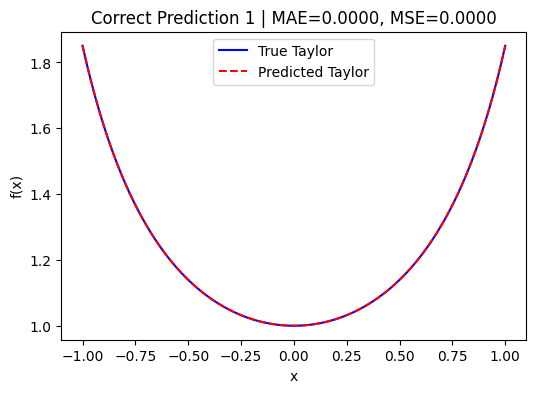

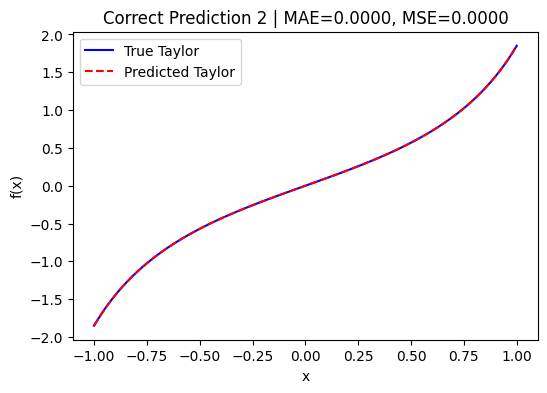

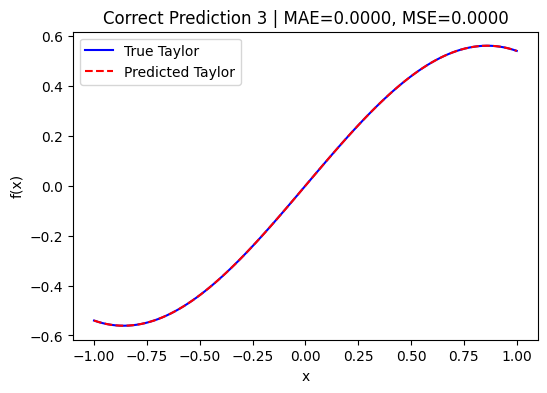

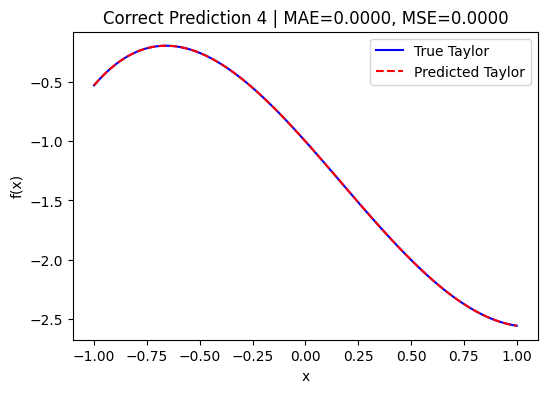

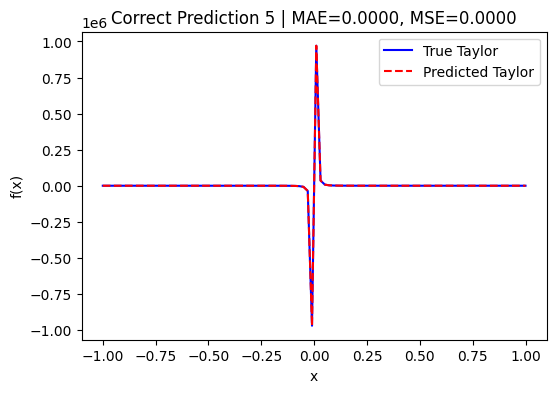

In [75]:
plot_taylor_samples_with_distance(correct_samples, title_prefix="Correct Prediction")


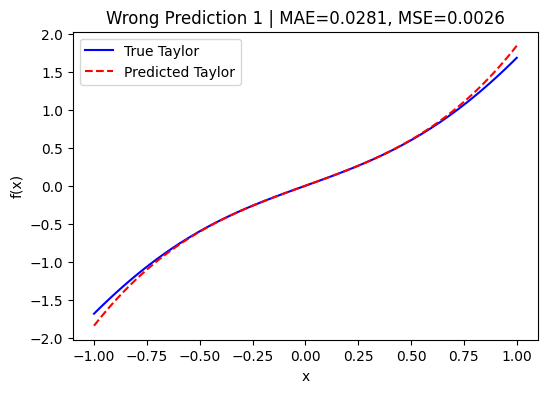

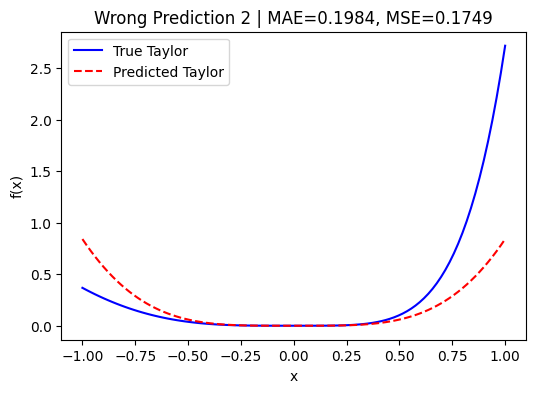

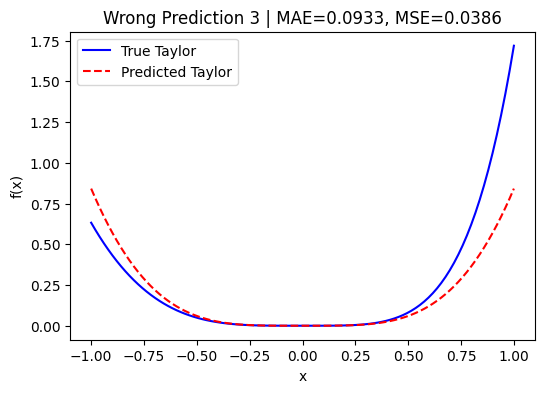

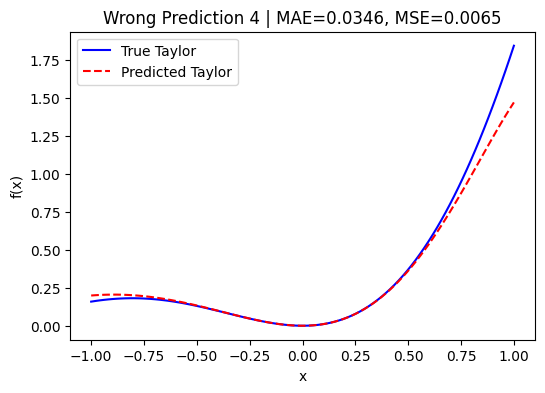

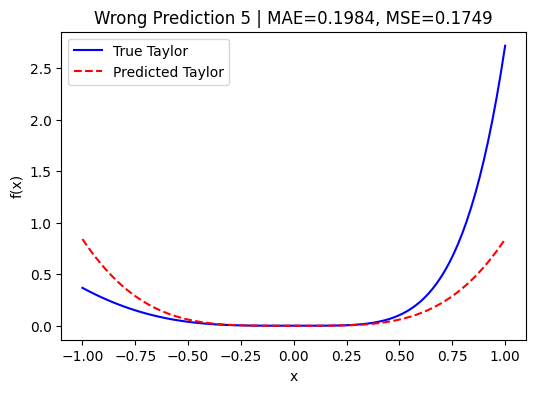

In [76]:
plot_taylor_samples_with_distance(wrong_samples, title_prefix="Wrong Prediction")

Created by Tommaso Vaccari